In [1]:
from hybrid_joint import *
from diffrax import *
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from controls import *

We consider
$$ \begin{cases} \mathrm{d}S_t = \sqrt{V_t} S_t \mathrm{d}\underline W^2_t \\ \mathrm{d}V_t = (\alpha + \beta V_t)\mathrm{d}t + \sigma_0 V_t^{\gamma_0} \mathrm{d} \underline B^H_t + \sigma_1 V_t^{\gamma_1} \mathrm{d}\underline W^1_t \end{cases} $$
as driven by the rough path above $(B^H, W^1, W^2)$, the limit of the lead-lag approximations with $B^H$ lagged w.r.t. $(W^1,W^2)$. We allow for arbitrary correlation structure:
$$B^H_t = \int_0^t (t-s)^{H- 1/2} \mathrm{d}B_s, \qquad \mathrm{d}[W^1, W^2] = \rho^{12}\mathrm{d}t, \quad \mathrm{d}[B,W^1] = \rho^{01}\mathrm{d}t, \quad \mathrm{d}[B, W^2] = \rho^{02}\mathrm{d}t $$
The interesting cases are when there is correlation between the noise driving the vol $(B^H, W^1)$ and the noise driving the price $W^2$, i.e. $\rho^{02} \neq 0$ or $\rho^{12} \neq 0$.
- If $\rho^{02} = 0$ lead-lag is not needed and we are in the usual gaussian rough path framework (with non-iid components, but the correlation is only between the brownians and does not cause divergence).
- If $\rho^{02} \neq 0$ lead-lag is needed to solve the system jointly. However it is still possible to solve first for $V$ and then for $S$.
- If $\rho^{01} \neq 0$ lead-lag is needed even to solve the equation for $V$, so this usage is more essential.



In [2]:
H = 0.1
M = 2
grid_points = 10000000
kappa = 1
T = 1.
print(T/grid_points)

1e-07


In [3]:
fine_times = jnp.linspace(0, T, grid_points)

In [135]:
fbm, bm1, bm2 = correlated_fbm_bm_bm(0.8, 0, 0, grid_points, T, 0.2, kappa)

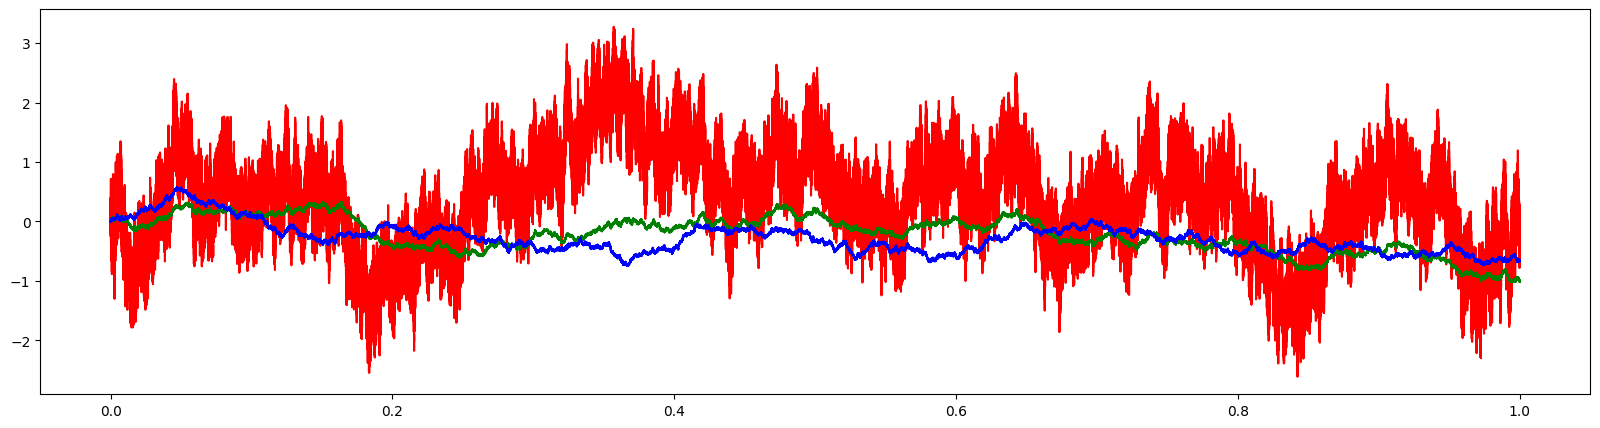

In [136]:
plt.figure(figsize=(20, 5))
pl_fbm = plt.plot(fine_times, fbm, color = "red")
pl_bm1 = plt.plot(fine_times, bm1, color = "green")
pl_bm2 = plt.plot(fine_times, bm2, color = "blue")

TODO:

- Lead-lag scheme for general case, test different (non-)degenerate cases for convergence DONE
- Check solution diverges when no lead-lag and correlation DONE
- Check solution is equal to no lead-lag iff there is no correlation DONE
- Check solution to S is exponential martingale STILL TODO

In [144]:
# Now that we have our "true noise", here are the parameters for subsampling from it
t0, t1 = 0, 1
epsilon = 0.0001
lag = epsilon
solver_epsilon = 0.1*epsilon
times = jnp.arange(t0, t1, epsilon)
every_nth_pt = int(grid_points*epsilon)

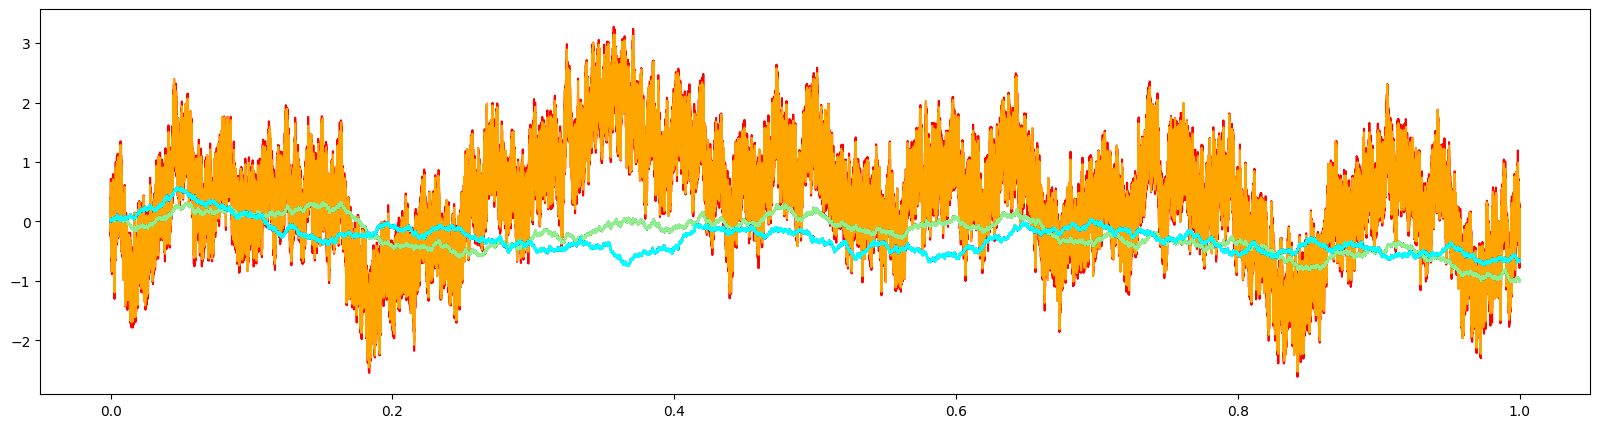

In [145]:
def evaluate_and_reshape_fun(fun):
    return lambda t: jnp.atleast_1d(fun(t))

# Create the controls; as before we subsample in order to test convergence (but this is only for testing purposes)
subsampled_bm1 = bm1[::every_nth_pt]
bm1_interp = LinearInterpolation(times, subsampled_bm1[:])
bm1_control = evaluate_and_reshape(bm1_interp.evaluate)

subsampled_bm2 = bm2[::every_nth_pt]
bm2_interp = LinearInterpolation(times, subsampled_bm2[:])
bm2_control = evaluate_and_reshape(bm2_interp.evaluate)

subsampled_fbm = fbm[::every_nth_pt]
fbm_interp = LinearInterpolation(times, subsampled_fbm[:])
fbm_fun = evaluate_and_reshape_fun(fbm_interp.evaluate)
fbm_control = evaluate_and_reshape(fbm_interp.evaluate)
fbm_lagged_control = lagged_control(fbm_fun, lag)

lead_lag_control = join_controls(fbm_lagged_control, join_controls(bm1_control, bm2_control))

# check that they are similar to the original
plt.figure(figsize=(20, 5))
plt.plot(fine_times, fbm[:], color = 'red')
plt.plot(times, subsampled_fbm[:], color = 'orange')

plt.plot(fine_times, bm1[:], color = 'green')
plt.plot(times, subsampled_bm1[:], color = 'lightgreen')

plt.plot(fine_times, bm2[:], color = 'blue')
plt.plot(times, subsampled_bm2[:], color = 'cyan')

$$ \begin{cases} \mathrm{d}S_t = \sqrt{V_t} S_t \mathrm{d}\underline W^2_t \\ \mathrm{d}V_t = (\alpha + \beta V_t)\mathrm{d}t + \sigma_0 V_t^{\gamma_0} \mathrm{d} \underline B^H_t + \sigma_1 V_t^{\gamma_1} \mathrm{d}\underline W^1_t \end{cases} $$

In [146]:
gamma0 = 1
gamma1 = 1.5
sigma0 = 0.2
sigma1 = 0.4
alpha = 1
beta = 1

y0 = jnp.array([1, 1])
drift = lambda t, y, args: jnp.array([0, alpha + beta*y[1]])
diffusion = lambda t, y, args: jnp.array([[0, 0, jnp.sqrt(y[1])*y[0]], [sigma0*jnp.power(y[1], gamma0), sigma1*jnp.power(y[1], gamma1), 0]])
saveat = SaveAt(ts = times)
terms = MultiTerm(ODETerm(drift), ControlTerm(diffusion, lead_lag_control))

In [147]:
solution = diffeqsolve(terms, Midpoint(), 0, 1, dt0 = solver_epsilon, max_steps=None, y0=y0, saveat=saveat)

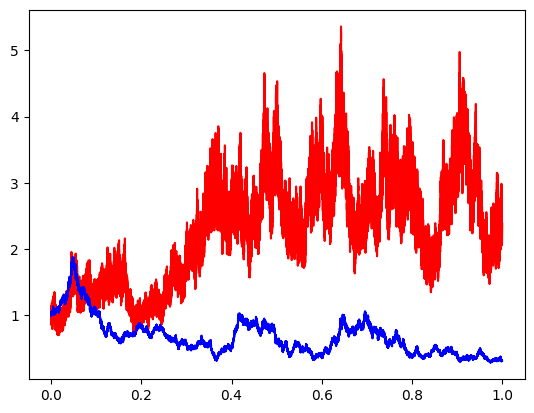

In [148]:
plt.plot(solution.ts[:], solution.ys[:, 1], color = "red")
plt.plot(solution.ts[:], solution.ys[:, 0], color = "blue")

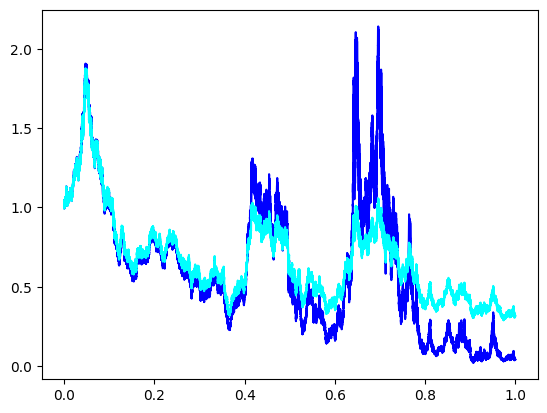

In [149]:
not_ll_control = join_controls(fbm_control, join_controls(bm1_control, bm2_control))
terms_no_ll = MultiTerm(ODETerm(drift), ControlTerm(diffusion, not_ll_control))
solution_no_ll = diffeqsolve(terms_no_ll, Midpoint(), 0, 1, dt0 = solver_epsilon, max_steps=None, y0=y0, saveat=saveat)
plt.plot(solution_no_ll.ts[:], solution_no_ll.ys[:, 0], color = "blue")
plt.plot(solution.ts[:], solution.ys[:, 0], color = "cyan")


# indeed, if (and only if) rho02, rho01 != 0, the no_ll solution diverges
# even without correlation, lead-lag converges faster than no lead-lag

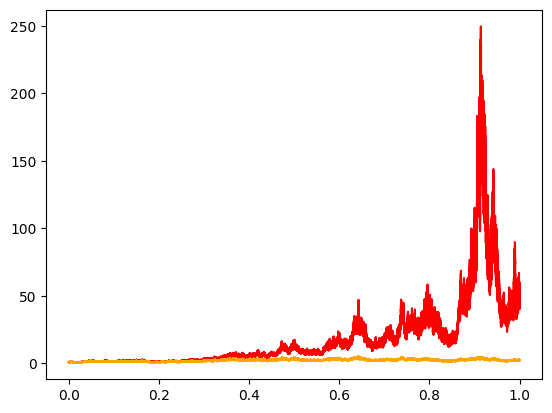

In [150]:
plt.plot(solution_no_ll.ts[:], solution_no_ll.ys[:, 1], color = "red")
plt.plot(solution.ts[:], solution.ys[:, 1], color = "orange")

# This is to see the divergence in the case of rho02 != 0 (this also causes divergence above). This is only present if the Lie bracket is non-zero.

epsilon = 0.0001 and solver_epsilon = 0.1*epsilon seem good enough for convergence when using lead-lag. Making solver_epsilon smalled doesn't give any improvement, but epsilon = 0.00001 is closer to the true solution.